#  Dashboard de Vulnerabilidade e Assistência Estudantil — UFPB Campus I

##  1. Sobre este notebook

Este notebook implementa, em Python, um **protótipo funcional** do produto descrito na seção
*"2.3 Desenho do produto"* do relatório do projeto. Ele reproduz, com os dados reais do modelo
dimensional (`fato_assistencia.csv` + dimensões), os três painéis propostos:

1. **Painel de Cobertura Institucional** — KPIs macro do Campus I;
2. **Matriz de Demanda Reprimida (IDPNA)** — dispersão cotistas x apoio social, por curso;
3. **Demografia da Vulnerabilidade** — perfil de raça/cor e sexo dos cursos mais críticos, frente
   à média do Campus;

mais um painel extra (**Mapa de Calor por Centro**), sugerido no cronograma da Semana 4 do
relatório ("mapa de calor de demanda reprimida por Centro de Ensino").


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: "%.2f" % x)
sns.set_theme(style="whitegrid")

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PATH_FATO = BASE_DIR / "data" / "processed" / "Fato" / "fato_assistencia.csv"
PATH_DIM_CURSO = BASE_DIR / "data" / "processed" / "Dimensões" / "dim_curso_ufpb_campus_1.csv"
PATH_DIM_CENTRO = BASE_DIR / "data" / "processed" / "Dimensões" / "dim_centro.csv"
PATH_DIM_CURSO_CENTRO = BASE_DIR / "data" / "processed" / "Dimensões" / "dim_curso_centro.csv"
PATH_DIM_RACA = BASE_DIR / "data" / "processed" / "Dimensões" / "dim_raca.csv"
PATH_DIM_SEXO = BASE_DIR / "data" / "processed" / "Dimensões" / "dim_sexo.csv"
PATH_DIM_TURNO = BASE_DIR / "data" / "processed" / "Dimensões" / "dim_turno.csv"

PATH_OUT_TABLES = BASE_DIR / "outputs" / "tables"
PATH_OUT_FIGURES = BASE_DIR / "outputs" / "figures"
PATH_OUT_TABLES.mkdir(parents=True, exist_ok=True)
PATH_OUT_FIGURES.mkdir(parents=True, exist_ok=True)

In [2]:
df_fato = pd.read_csv(PATH_FATO, sep=";")

df_curso = pd.read_csv(PATH_DIM_CURSO, sep=";")
df_fato = df_fato.merge(df_curso[["CO_CURSO", "NO_CURSO"]], on="CO_CURSO", how="left")

df_centro = pd.read_csv(PATH_DIM_CENTRO, sep=";")
df_fato = df_fato.merge(df_centro, on="ID_CENTRO", how="left")

df_raca = pd.read_csv(PATH_DIM_RACA, sep=";").rename(columns={"DESCRICAO": "RACA_DESCRICAO"})
df_fato = df_fato.merge(df_raca[["ID_RACA", "RACA_DESCRICAO"]], on="ID_RACA", how="left")

df_sexo = pd.read_csv(PATH_DIM_SEXO, sep=";").rename(columns={"DESCRICAO": "SEXO_DESCRICAO"})
df_fato = df_fato.merge(df_sexo[["ID_SEXO", "SEXO_DESCRICAO"]], on="ID_SEXO", how="left")

df_turno = pd.read_csv(PATH_DIM_TURNO, sep=";").rename(columns={"DESCRICAO": "TURNO_DESCRICAO"})
df_fato = df_fato.merge(df_turno[["ID_TURNO", "TURNO_DESCRICAO"]], on="ID_TURNO", how="left")

print(f"Base carregada: {len(df_fato):,} linhas | {df_fato['TOTAL_ALUNOS'].sum():,} alunos")

Base carregada: 2,468 linhas | 31,210 alunos


---
##  2. Painel de Cobertura Institucional (KPIs)

Indicadores macro do Campus I, conforme especificado no relatório: **população total**,
**percentual de cotistas** e **taxa de cobertura atual da PRAPE**.

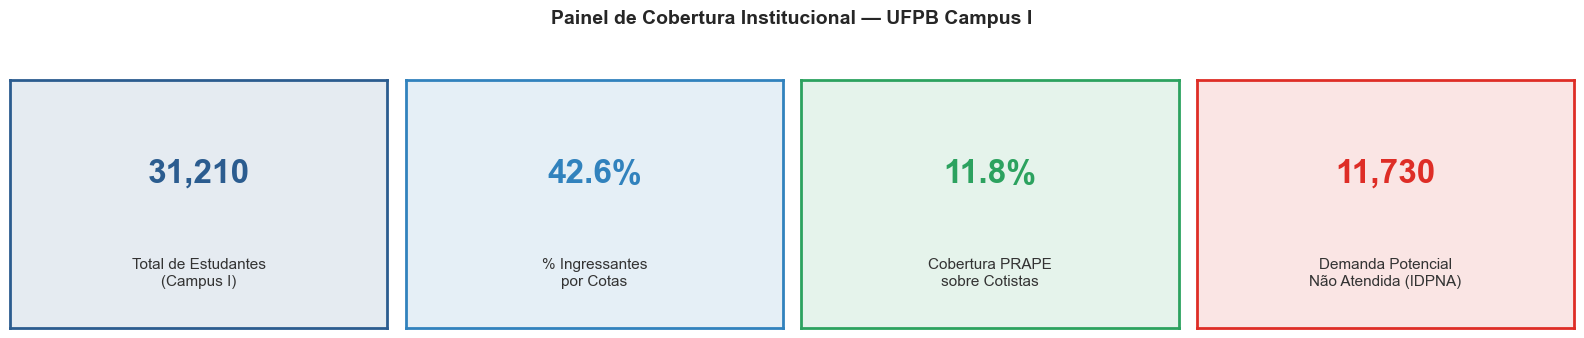

,Indicador,Valor
0,Total de estudantes,31210.00
1,% cotistas,42.62
2,Cobertura PRAPE (sobre cotistas),11.82
3,Demanda potencial não atendida (IDPNA),11730.00


In [14]:
total_alunos = df_fato["TOTAL_ALUNOS"].sum()
total_cotistas = df_fato.loc[df_fato["IN_RESERVA_VAGAS"] == 1, "TOTAL_ALUNOS"].sum()
total_assistidos = df_fato.loc[df_fato["RECEBE_AUXILIO"] == 1, "TOTAL_ALUNOS"].sum()
total_idpna = df_fato["TOTAL_IDPNA"].sum()

cotistas_df = df_fato[df_fato["IN_RESERVA_VAGAS"] == 1]
total_assistidos_cotistas = cotistas_df.loc[cotistas_df["RECEBE_AUXILIO"] == 1, "TOTAL_ALUNOS"].sum()
pct_cobertura_prape = total_assistidos_cotistas / total_cotistas * 100

kpis = [
    ("Total de Estudantes\n(Campus I)", f"{total_alunos:,.0f}", "#2b5c8f"),
    ("% Ingressantes\npor Cotas", f"{pct_cotistas:.1f}%", "#3182bd"),
    ("Cobertura PRAPE\nsobre Cotistas", f"{pct_cobertura_prape:.1f}%", "#2ca25f"),
    ("Demanda Potencial\nNão Atendida (IDPNA)", f"{total_idpna:,.0f}", "#de2d26"),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, (titulo, valor, cor) in zip(axes, kpis):
    ax.set_facecolor(cor)
    ax.patch.set_alpha(0.12)
    for spine in ax.spines.values():
        spine.set_edgecolor(cor)
        spine.set_linewidth(2)
    ax.text(0.5, 0.62, valor, ha="center", va="center", fontsize=24, fontweight="bold", color=cor)
    ax.text(0.5, 0.22, titulo, ha="center", va="center", fontsize=11, color="#333333")
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Painel de Cobertura Institucional — UFPB Campus I", fontweight="bold", fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig(PATH_OUT_FIGURES / "dash_01_kpis.png", dpi=150, bbox_inches="tight")
plt.show()

resumo_kpis = pd.DataFrame({
    "Indicador": ["Total de estudantes", "% cotistas", "Cobertura PRAPE (sobre cotistas)",
                   "Demanda potencial não atendida (IDPNA)"],
    "Valor": [total_alunos, round(pct_cotistas, 2), round(pct_cobertura_prape, 2), total_idpna],
})
resumo_kpis.to_csv(PATH_OUT_TABLES / "dash_kpis_institucionais.csv", index=False, sep=";")
resumo_kpis

---
##  3. Matriz de Demanda Reprimida (IDPNA) por Curso

Dispersão (*scatter plot*) entre o **volume de cotistas** e o **volume de estudantes com apoio
social** por curso. Cursos **abaixo da linha diagonal** (y = x) recebem, em números absolutos,
menos apoio social do que seu contingente de cotistas — quanto mais distante da diagonal, maior
o déficit de cobertura (IDR_C).

In [10]:
matriz_curso = (
    df_fato.groupby(["CO_CURSO", "NO_CURSO", "CENTRO"])
    .apply(
        lambda x: pd.Series({
            "TOTAL_ALUNOS": x["TOTAL_ALUNOS"].sum(),
            "TOTAL_COTISTAS": x.loc[x["IN_RESERVA_VAGAS"] == 1, "TOTAL_ALUNOS"].sum(),
            "TOTAL_COM_APOIO_SOCIAL": x.loc[x["RECEBE_AUXILIO"] == 1, "TOTAL_ALUNOS"].sum(),
            "TOTAL_IDPNA": x["TOTAL_IDPNA"].sum(),
        }),
        include_groups=False,
    )
    .reset_index()
)
matriz_curso["IDPNA (% cotistas desassistidos)"] = np.where(
    matriz_curso["TOTAL_COTISTAS"] > 0,
    (matriz_curso["TOTAL_IDPNA"] / matriz_curso["TOTAL_COTISTAS"] * 100).round(2),
    np.nan,
)
matriz_curso = matriz_curso.sort_values("TOTAL_IDPNA", ascending=False)
matriz_curso.to_csv(PATH_OUT_TABLES / "dash_matriz_demanda_reprimida.csv", index=False, sep=";")
matriz_curso.head(15)

,CO_CURSO,NO_CURSO,CENTRO,TOTAL_ALUNOS,TOTAL_COTISTAS,TOTAL_COM_APOIO_SOCIAL,TOTAL_IDPNA,IDPNA (% cotistas desassistidos)
15,13418,PEDAGOGIA,CE,1567,697,108,642,92.11
3,13397,CIÊNCIAS CONTÁBEIS,CCSA,1319,566,41,542,95.76
4,13398,DIREITO,CCJ,1041,425,120,375,88.24
38,107548,LETRAS - LÍNGUA PORTUGUESA,CCHLA,721,325,33,303,93.23
19,13424,MEDICINA,CCM,779,348,179,269,77.30
1,13395,ADMINISTRAÇÃO,CCSA,674,280,28,258,92.14
39,107549,LETRAS - INGLÊS,CCHLA,567,239,15,228,95.40
14,13417,SERVIÇO SOCIAL,CCHLA,517,249,27,227,91.16
54,122924,PEDAGOGIA - EDUCAÇÃO DO CAMPO,CE,525,244,23,223,91.39
25,13430,ENGENHARIA MECÂNICA,CT,645,277,77,220,79.42


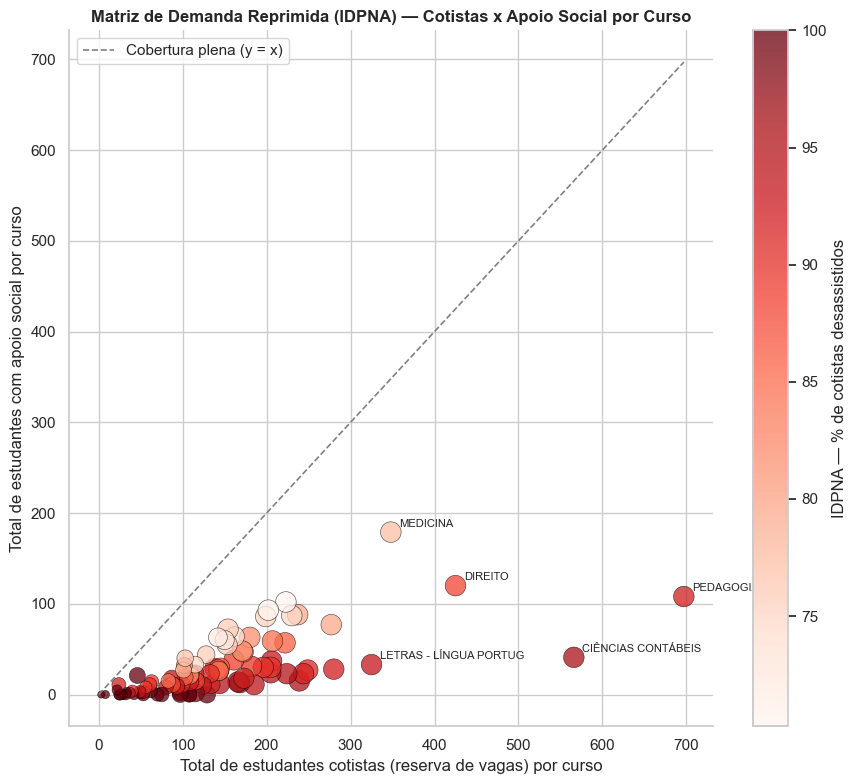

In [12]:
fig, ax = plt.subplots(figsize=(9, 8))

scatter = ax.scatter(
    matriz_curso["TOTAL_COTISTAS"],
    matriz_curso["TOTAL_COM_APOIO_SOCIAL"],
    s=matriz_curso["TOTAL_ALUNOS"].clip(upper=400) / 2 + 20,
    c=matriz_curso["IDPNA (% cotistas desassistidos)"],
    cmap="Reds",
    alpha=0.75,
    edgecolor="black",
    linewidth=0.4,
)

limite = max(matriz_curso["TOTAL_COTISTAS"].max(), matriz_curso["TOTAL_COM_APOIO_SOCIAL"].max())
ax.plot([0, limite], [0, limite], linestyle="--", color="gray", linewidth=1.2, label="Cobertura plena (y = x)")

# Anota os 5 cursos com maior déficit absoluto (TOTAL_IDPNA)
for _, row in matriz_curso.head(5).iterrows():
    ax.annotate(
        row["NO_CURSO"][:22],
        (row["TOTAL_COTISTAS"], row["TOTAL_COM_APOIO_SOCIAL"]),
        textcoords="offset points", xytext=(6, 4), fontsize=8,
    )

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("IDPNA — % de cotistas desassistidos")

ax.set_xlabel("Total de estudantes cotistas (reserva de vagas) por curso")
ax.set_ylabel("Total de estudantes com apoio social por curso")
ax.set_title("Matriz de Demanda Reprimida (IDPNA) — Cotistas x Apoio Social por Curso", fontweight="bold")
ax.legend(loc="upper left")
sns.despine()
plt.tight_layout()
plt.savefig(PATH_OUT_FIGURES / "dash_02_matriz_idr.png", dpi=150)
plt.show()

---
##  4. Demografia da Vulnerabilidade — Cursos Críticos x Média do Campus

Comparação do perfil de **raça/cor** e **sexo** dos 10 cursos com maior demanda potencial não
atendida (`TOTAL_IDPNA`, calculados na Pergunta 3 do `04_analise_exploratoria.ipynb`) frente à
média geral do Campus I.

In [6]:
top10_cursos = matriz_curso.sort_values("TOTAL_IDPNA", ascending=False).head(10)["CO_CURSO"]
df_top10 = df_fato[df_fato["CO_CURSO"].isin(top10_cursos)]

def perfil_percentual(df, coluna_grupo):
    dist = df.groupby(coluna_grupo)["TOTAL_ALUNOS"].sum()
    return (dist / dist.sum() * 100).round(2)

perfil_raca_campus = perfil_percentual(df_fato, "RACA_DESCRICAO")
perfil_raca_top10 = perfil_percentual(df_top10, "RACA_DESCRICAO")

perfil_sexo_campus = perfil_percentual(df_fato, "SEXO_DESCRICAO")
perfil_sexo_top10 = perfil_percentual(df_top10, "SEXO_DESCRICAO")

comp_raca = pd.concat([perfil_raca_campus, perfil_raca_top10], axis=1,
                       keys=["% Média do Campus", "% Top 10 cursos críticos"]).fillna(0)
comp_sexo = pd.concat([perfil_sexo_campus, perfil_sexo_top10], axis=1,
                       keys=["% Média do Campus", "% Top 10 cursos críticos"]).fillna(0)

comp_raca.to_csv(PATH_OUT_TABLES / "dash_demografia_raca.csv", sep=";")
comp_sexo.to_csv(PATH_OUT_TABLES / "dash_demografia_sexo.csv", sep=";")

display(comp_raca)
display(comp_sexo)

,% Média do Campus,% Top 10 cursos críticos
RACA_DESCRICAO,,
Amarela,0.55,0.62
Branca,30.75,29.81
Indígena,0.13,0.13
Não informado,16.26,16.65
Parda,46.22,46.62
Preta,6.09,6.16


,% Média do Campus,% Top 10 cursos críticos
SEXO_DESCRICAO,,
Feminino,48.22,42.17
Masculino,51.78,57.83


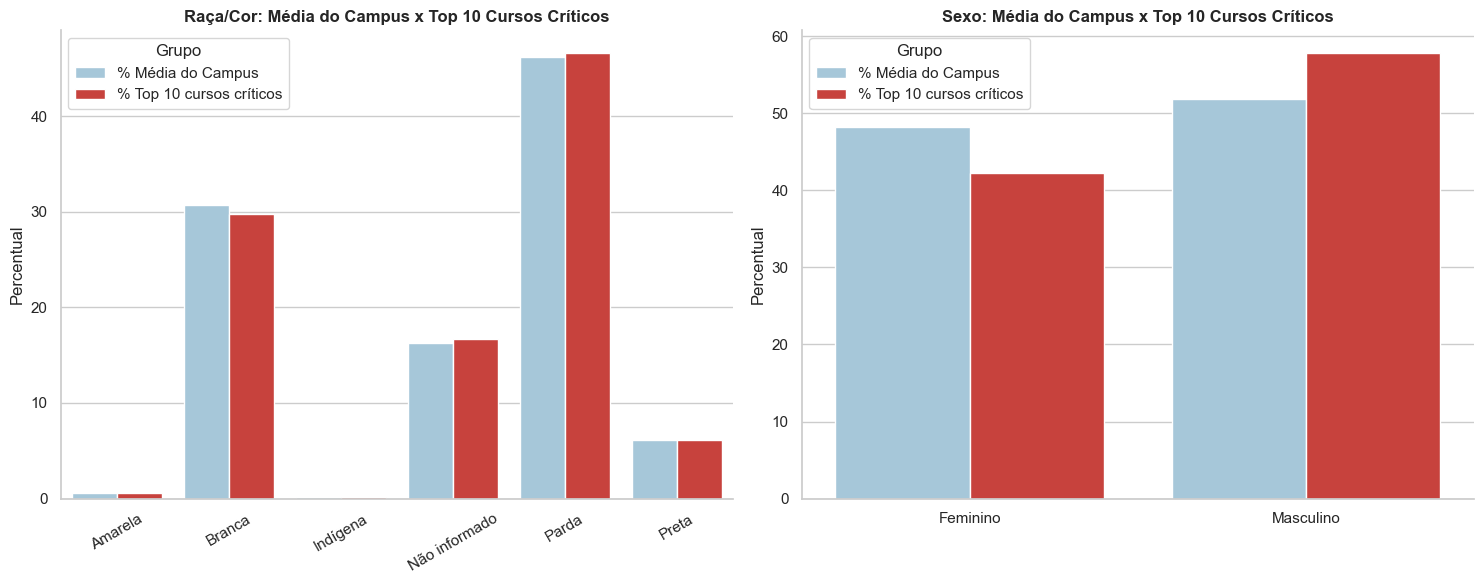

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

comp_raca.reset_index().melt(id_vars="RACA_DESCRICAO", var_name="Grupo", value_name="Percentual").pipe(
    lambda d: sns.barplot(data=d, x="RACA_DESCRICAO", y="Percentual", hue="Grupo",
                           palette=["#9ecae1", "#de2d26"], ax=axes[0])
)
axes[0].set_title("Raça/Cor: Média do Campus x Top 10 Cursos Críticos", fontweight="bold")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

comp_sexo.reset_index().melt(id_vars="SEXO_DESCRICAO", var_name="Grupo", value_name="Percentual").pipe(
    lambda d: sns.barplot(data=d, x="SEXO_DESCRICAO", y="Percentual", hue="Grupo",
                           palette=["#9ecae1", "#de2d26"], ax=axes[1])
)
axes[1].set_title("Sexo: Média do Campus x Top 10 Cursos Críticos", fontweight="bold")
axes[1].set_xlabel("")

sns.despine()
plt.tight_layout()
plt.savefig(PATH_OUT_FIGURES / "dash_03_demografia.png", dpi=150)
plt.show()

---
##  5. Mapa de Calor — Demanda Reprimida por Centro de Ensino

Painel adicional sugerido no cronograma do relatório (Semana 4: *"mapa de calor de demanda
reprimida por Centro de Ensino"*). Calculamos o IDR_C agregado por **Centro** e por **Turno**.

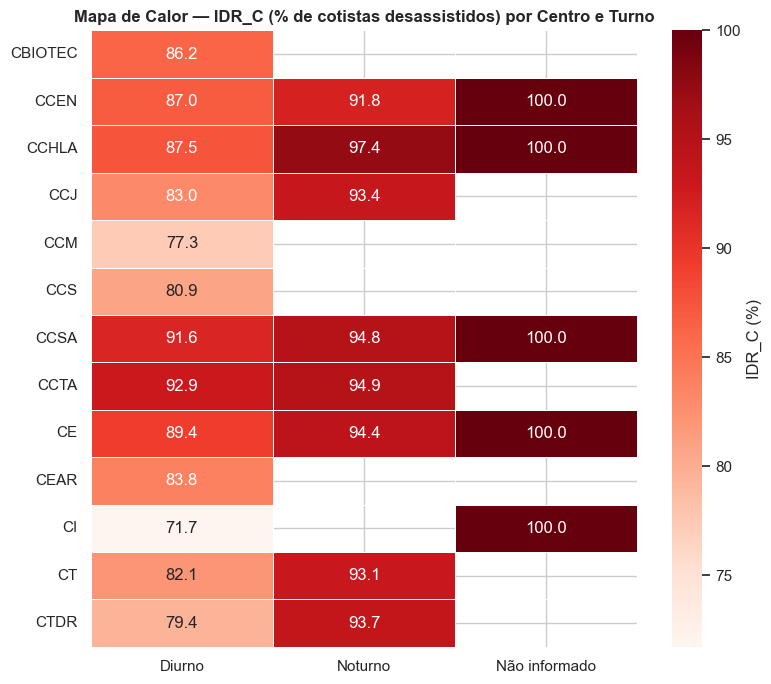

In [8]:
mapa_turno_grupo = {
    "Matutino": "Diurno", "Vespertino": "Diurno", "Integral": "Diurno",
    "Noturno": "Noturno", "Não informado": "Não informado",
}
df_fato["GRUPO_TURNO"] = df_fato["TURNO_DESCRICAO"].map(mapa_turno_grupo)

heat = (
    df_fato.groupby(["CENTRO", "GRUPO_TURNO"])
    .apply(
        lambda x: pd.Series({
            "TOTAL_COTISTAS": x.loc[x["IN_RESERVA_VAGAS"] == 1, "TOTAL_ALUNOS"].sum(),
            "TOTAL_IDPNA": x["TOTAL_IDPNA"].sum(),
        }),
        include_groups=False,
    )
    .reset_index()
)
heat["IDR_C"] = np.where(
    heat["TOTAL_COTISTAS"] > 0, (heat["TOTAL_IDPNA"] / heat["TOTAL_COTISTAS"] * 100).round(2), np.nan
)
heat_pivot = heat.pivot(index="CENTRO", columns="GRUPO_TURNO", values="IDR_C")
heat_pivot.to_csv(PATH_OUT_TABLES / "dash_heatmap_centro_turno.csv", sep=";")

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(heat_pivot, annot=True, fmt=".1f", cmap="Reds", linewidths=0.5, cbar_kws={"label": "IDR_C (%)"}, ax=ax)
ax.set_title("Mapa de Calor — IDR_C (% de cotistas desassistidos) por Centro e Turno", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(PATH_OUT_FIGURES / "dash_04_heatmap_centro.png", dpi=150)
plt.show()

---
##  6. Exportação

Todas as tabelas agregadas usadas neste protótipo já foram salvas em `outputs/tables/` durante a
execução das seções anteriores:

| Arquivo | Conteúdo |
| --- | --- |
| `dash_kpis_institucionais.csv` | KPIs macro do Campus I (Painel 1) |
| `dash_matriz_demanda_reprimida.csv` | Cotistas x Apoio Social x IDpna por curso (Painel 2) |
| `dash_demografia_raca.csv` / `dash_demografia_sexo.csv` | Perfil demográfico: Campus x Top 10 cursos críticos (Painel 3) |
| `dash_heatmap_centro_turno.csv` | IDPNA por Centro e Turno (Painel 4) |